# MNIST Hyperparameter Search

Fully-connected MNIST classifier와 함께 **4가지 하이퍼파라미터 탐색 전략**(Grid / Random / Bayesian / Hyperband)을 비교하고, `joblib` 기반 병렬 실험 파이프라인으로 학습·평가·분석합니다.

---

### **Workflow Explanation**

This Code follows a structured pipeline for building, optimizing, and evaluating deep learning models through various hyperparameter search strategies.

The following diagram summarizes the overall flow:

<img src="./data/workflow.png" alt="Result Flowchart" width="1500"/>

### **1. Start**

The process begins with **model creation** through the `build_model` function.

### **2. Model Creation (`build_model`)**

- **Neural Network Structure**  
  Based on given hyperparameters (`num_layers`, `units_per_layer`), the architecture is constructed dynamically.

- **Apply L2 Regularization and Dropout**  
  Each hidden layer applies L2 regularization and dropout to prevent overfitting.

- **Softmax Output Layer**  
  A final dense layer with Softmax activation is added for multi-class classification (10 classes).

### **3. Hyperparameter Search (`HyperparameterSearch`)**

Different search strategies are available:

- **Grid Search**  
  Exhaustive exploration of all predefined combinations.

- **Random Search**  
  Random sampling of hyperparameter sets.

- **Bayesian Optimization**  
  Guided search using probabilistic modeling to find promising hyperparameters.

- **Hyperband Search**  
  Efficient resource allocation to quickly discard poor models.

Depending on the chosen search strategy, the model is trained accordingly.

### **4. Model Training and Evaluation (`train_and_evaluate_model`)**

- **Optimizer**  
  All models are compiled using the **Adam Optimizer**.

- **Apply EarlyStopping**  
  Training is halted if validation loss does not improve, preventing overfitting and saving resources.

- **Evaluation**  
  After training, models are evaluated on train, validation, and test datasets separately.

### **5. Parallel Processing (`run_search`)**

- **Use joblib Parallel**  
  Model training tasks are distributed across multiple CPU cores to reduce overall training time.

- **Reduce Training Time via Parallelization**  
  Significant reduction in runtime was achieved through parallelized execution of experiments.

### **6. Save Results**

- All experiment results (hyperparameters, metrics) are saved as a **CSV file** for future analysis.

### **7. End**

The workflow concludes once all models are trained, evaluated, and results are recorded.


### **Selected Hyperparameter Setting**

| Parameter                | Value           |
|---------------------------|-----------------|
| Hidden Layer Structure    | (256,)           |
| Activation Function       | swish            |
| Optimizer                 | adam             |
| Batch Size                | 64               |
| Dropout Rate              | 0.5              |
| Regularization Type       | L2               |
| L2 Regularization Factor  | 0.0              |

### **Performance Metrics**

| Dataset      | Loss    | Accuracy |
|--------------|---------|----------|
| Training Set | 0.0163  | 0.9957   |
| Validation Set | 0.0638 | 0.9821   |
| Test Set     | 0.0585  | 0.9834   |


---
# **Code**

### **Packages**
Imported the necessary packages required to run the code.

In [ ]:
# Basic Libraries
import os
import random
import glob
import ast
import time
from itertools import product
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential, regularizers
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Hyperparameter Tuning
from keras_tuner.tuners import BayesianOptimization, Hyperband

# Parallel Processing
from joblib import Parallel, delayed

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### **Hyperparameter Search**
This section describes the methods used to search for the optimal hyperparameters to improve model performance.

In [ ]:
class HyperparameterSearch:
    """Define the basic hyperparameter search space and search methods."""

    # Candidate numbers of units for hidden layers during random search
    # (Used only in random search. In other search, predefined layer structures are used instead.)
    UNIT_RANDOM_SEARCH = [32, 64, 96, 128, 160, 192, 224, 256]

    # Activation functions to try during tuning
    ACTIVATIONS = ['relu', 'swish']

    # Optimizers to consider
    OPTIMIZERS = ['adam']

    # Batch sizes to explore
    BATCH_SIZES = [64, 128]

    # Dropout rates to prevent overfitting
    DROPOUT_RATES = [0.0, 0.2, 0.5]

    # L2 regularization strength values (Higher values may cause model performance to collapse severely.)
    REGULARIZATION_VALUES = [0.0, 0.001, 0.01]

    # Predefined hidden layer configurations for grid search 
    FIXED_LAYER_OPTIONS = [
        (64,), (64, 32), (128, 64), (128, 64, 32),
        (256,), (256, 128), (256, 128, 64),
        (512,), (512, 256), (512, 256, 128),
        (1024,)
    ]

    @staticmethod
    def grid():
        """
        Perform a full grid search by generating all possible hyperparameter combinations.
        Returns:
            list of hyperparameter tuples
        """
        return list(product(
            HyperparameterSearch.FIXED_LAYER_OPTIONS,
            HyperparameterSearch.REGULARIZATION_VALUES,
            HyperparameterSearch.ACTIVATIONS,
            HyperparameterSearch.OPTIMIZERS,
            HyperparameterSearch.BATCH_SIZES,
            HyperparameterSearch.DROPOUT_RATES
        ))

    @staticmethod
    def random(n_samples=10):
        """
        Perform a random search by sampling n combinations randomly.
        Args:
            n_samples (int): Number of random samples to generate.
        Returns:
            list of randomly sampled hyperparameter tuples
        """
        return [(
            tuple(np.random.choice(HyperparameterSearch.UNIT_RANDOM_SEARCH, np.random.randint(1, 4))),  # Random layer configuration
            10 ** np.random.uniform(-5, -2),                                                       # Random L2 value
            random.choice(HyperparameterSearch.ACTIVATIONS),
            random.choice(HyperparameterSearch.OPTIMIZERS),
            random.choice(HyperparameterSearch.BATCH_SIZES),
            random.choice(HyperparameterSearch.DROPOUT_RATES)
        ) for _ in range(n_samples)]

    @staticmethod
    def _model_fn(hp, regularizer_type='l2'):
        """
        Build a model based on the hyperparameters selected by Keras Tuner.
        Args:
            hp: Hyperparameters object provided by the tuner.
            regularizer_type (str): Regularization type, default is 'l2'.
        Returns:
            Compiled Keras model.
        """
        # Sample hyperparameters
        num_layers = hp.Int('num_layers', 1, 3)  # Number of hidden layers
        units = [hp.Int(f'units_{i}', 32, 256, step=32) for i in range(num_layers)]
        reg_val = hp.Float('reg_value', 1e-5, 1e-2, sampling='log')
        activation = hp.Choice('activation', HyperparameterSearch.ACTIVATIONS)
        optimizer = hp.Choice('optimizer', HyperparameterSearch.OPTIMIZERS)
        batch_size = hp.Choice('batch_size', HyperparameterSearch.BATCH_SIZES)
        dropout = hp.Choice('dropout', HyperparameterSearch.DROPOUT_RATES)

        # Build and compile the model
        model = build_model(units, reg_val, activation=activation, regularizer_type=regularizer_type, dropout=dropout)
        model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model

    @staticmethod
    def bayesian_search(x_train, y_train, x_valid, y_valid, regularizer_type='l2', n_trials=10):
        """
        Perform hyperparameter search using Bayesian Optimization.
        Args:
            x_train, y_train: Training dataset
            x_valid, y_valid: Validation dataset
            regularizer_type (str): Regularization type
            n_trials (int): Number of Bayesian trials
        Returns:
            Best hyperparameter configuration as a tuple
        """
        # Set up the Bayesian tuner
        tuner = BayesianOptimization(
            lambda hp: HyperparameterSearch._model_fn(hp, regularizer_type),
            objective='val_accuracy',
            max_trials=n_trials,
            directory='tuner_dir',
            project_name='bayesian_search'
        )

        # Perform the search
        tuner.search(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid), verbose=0)

        # Extract the best hyperparameters
        best_hp = tuner.get_best_hyperparameters(1)[0]
        num_layers = best_hp.get('num_layers')

        return (
            tuple(best_hp.get(f'units_{i}') for i in range(num_layers)),
            best_hp.get('reg_value'),
            best_hp.get('activation'),
            best_hp.get('optimizer'),
            best_hp.get('batch_size'),
            best_hp.get('dropout')
        )

    @staticmethod
    def hyperband_search(x_train, y_train, x_valid, y_valid, regularizer_type='l2', max_epochs=20):
        """
        Perform hyperparameter search using Hyperband.
        Args:
            x_train, y_train: Training dataset
            x_valid, y_valid: Validation dataset
            regularizer_type (str): Regularization type
            max_epochs (int): Maximum number of epochs per trial
        Returns:
            Best hyperparameter configuration as a tuple
        """
        # Set up the Hyperband tuner
        tuner = Hyperband(
            lambda hp: HyperparameterSearch._model_fn(hp, regularizer_type),
            objective='val_accuracy',
            max_epochs=max_epochs,
            factor=3,
            directory='tuner_dir',
            project_name='hyperband_search'
        )

        # Perform the search
        tuner.search(x_train, y_train, epochs=20, validation_data=(x_valid, y_valid), verbose=0)

        # Extract the best hyperparameters
        best_hp = tuner.get_best_hyperparameters(1)[0]
        num_layers = best_hp.get('num_layers')

        return (
            tuple(best_hp.get(f'units_{i}') for i in range(num_layers)),
            best_hp.get('reg_value'),
            best_hp.get('activation'),
            best_hp.get('optimizer'),
            best_hp.get('batch_size'),
            best_hp.get('dropout')
        )


### **Build Model**
Build a simple fully connected neural network with L2 regularization.

In [169]:
def build_model(units_per_layer, reg_value, input_shape=(28, 28), regularizer_type='l2', activation='relu', dropout=0.0):
    """
    Build a simple fully connected neural network with L2 regularization.

    Args:
        units_per_layer: Number of units for each hidden layer.
        reg_value: Regularization strength.
        input_shape: Shape of the input data. Default is (28, 28) for MNIST.
        regularizer_type: Type of regularization ('l2' by default).
        activation: Activation function to use. Default is 'relu' (optionally 'swish' supported).
        dropout: Dropout rate applied after each dense layer. Default is 0.0 (no dropout).

    Returns:
        tf.keras.Model: A compiled Keras Sequential model ready for training.
    """

    # Apply L2 regularization (fixed to L2 for now)
    regularizer = regularizers.l2(reg_value)

    model = models.Sequential([layers.Flatten(input_shape=input_shape)])

    for units in units_per_layer:
        model.add(layers.Dense(units, activation=activation, kernel_regularizer=regularizer))
        if dropout > 0.0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(10, activation='softmax'))

    return model


### **Train and Evaluate Model**

Train a compiled model with validation and return performance metrics.

In [ ]:
def train_and_evaluate_model(model, x_train, y_train, x_valid, y_valid, optimizer='adam', batch_size=128, callbacks=None):
    """
    Compile, train, and evaluate a given model.

    Args:
        model: Model to train.
        x_train: Training input data.
        y_train: Training target labels.
        x_valid: Validation input data.
        y_valid: Validation target labels.
        optimizer: Optimizer to use for training. Default is 'adam'.
        batch_size: Batch size for training. Default is 128.
        callbacks: List of callbacks to use during training. If None, EarlyStopping is applied.

    Returns:
        tuple: (train_loss, train_accuracy, validation_loss, validation_accuracy, training_history)
    """

    # Set EarlyStopping callback if not provided
    if callbacks is None:
        callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

    # Compile the model
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit( x_train, y_train, validation_data=(x_valid, y_valid), epochs=20, callbacks=callbacks, batch_size=batch_size)

    # Evaluate performance on training data
    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)

    # Evaluate performance on validation data
    val_loss, val_acc = model.evaluate(x_valid, y_valid, verbose=0)

    return train_loss, train_acc, val_loss, val_acc, history

def run_one_setting(params, x_train, y_train, x_valid, y_valid, x_test, y_test, regularizer_type, search_label, callbacks=None):
    """
    Build, train, evaluate a model based on the given hyperparameters and return the results.

    Args:
        params: Hyperparameter configuration (layers, reg_value, activation, optimizer, batch_size, dropout).
        x_train, y_train: Training dataset.
        x_valid, y_valid: Validation dataset.
        x_test, y_test: Test dataset.
        regularizer_type: Type of regularization.
        search_label: Label indicating which search method was used (e.g., 'Grid', 'Random', 'Bayesian').
        callbacks: List of callbacks to use during training.

    Returns:
        dict: Dictionary containing hyperparameter settings and evaluation metrics.
    """

    # Unpack the hyperparameters
    layers_cfg, reg_val, activation, optimizer, batch_size, dropout = params

    # Build the model with the given configuration
    model = build_model( layers_cfg, reg_val, activation=activation, regularizer_type=regularizer_type, dropout=dropout)

    # Train and evaluate the model on training and validation data
    train_loss, train_acc, val_loss, val_acc, history = train_and_evaluate_model( model, x_train, y_train, x_valid, y_valid, optimizer=optimizer, batch_size=batch_size, callbacks=callbacks)

    # Evaluate the model on the test data
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    # Collect all results and hyperparameters into a dictionary
    res = {
        "Search": search_label,
        "Layers/units": layers_cfg,          # Layer structure (e.g., [128, 64, 32])
        "Regularizer": regularizer_type,
        "Reg_Val": reg_val,
        "Activation": activation,
        "Optimizer": optimizer,
        "Batch_Size": batch_size,
        "Dropout": dropout,
        "Tra_Loss": float(train_loss),        # Final training loss
        "Tra_Acc": float(train_acc),          # Final training accuracy
        "Val_Loss": float(val_loss),          # Final validation loss
        "Val_Acc": float(val_acc),            # Final validation accuracy
        "Test_Loss": float(test_loss),        # Final test loss
        "Test_Acc": float(test_acc),          # Final test accuracy
    }

    return res

### **Run Hyperparameter Search**

Perform hyperparameter search on the MNIST dataset using search strategies and summarize the results.

In [ ]:
def run_search(search_type='grid', n_samples=10, regularizer_type='l2', callbacks=None):
    """
    Perform hyperparameter search on the MNIST dataset using the specified search method.

    Args:
        search_type: Search strategy to use ('grid', 'random', 'bayesian', 'hyperband').
        n_samples: Number of samples for random or bayesian search. Default is 10.
        regularizer_type: Type of regularization to apply. Default is 'l2'.
        callbacks: List of Keras callbacks to apply during training. Default is EarlyStopping if None.

    Returns:
        pd.DataFrame: DataFrame containing hyperparameter settings and corresponding evaluation results.
    """


    # Load and preprocess MNIST data
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    x_valid, y_valid = x_train[-10000:], y_train[-10000:]
    x_train, y_train = x_train[:50000], y_train[:50000]

    # Select search method and generate parameter list
    search_methods = {
        'grid': (HyperparameterSearch.grid, "Grid"),
        'random': (lambda: HyperparameterSearch.random(n_samples), "Random"),
        'bayesian': (lambda: [HyperparameterSearch.bayesian_search(x_train, y_train, x_valid, y_valid, regularizer_type, n_samples)], "Bayesian"),
        'hyperband': (lambda: [HyperparameterSearch.hyperband_search(x_train, y_train, x_valid, y_valid, regularizer_type)], "Hyperband")
    }
    

    param_func, search_label = search_methods[search_type]
    param_list = param_func()

    # Define single run function
    def run_setting(params): return run_one_setting(params, x_train, y_train, x_valid, y_valid, x_test, y_test,regularizer_type, search_label, callbacks)

    # Run all settings in parallel
    results = Parallel(n_jobs=-1)( delayed(run_setting)(params) for params in param_list)

    # Format results
    df = pd.DataFrame([{
        "Search_Type": res["Search"],
        "Layer_Structure": str(res["Layers/units"]),
        "Hyperparameters": str({
            "activation": res["Activation"],
            "optimizer": res["Optimizer"],
            "batch_size": res["Batch_Size"],
            "dropout": res["Dropout"],
            "regularizer": res["Regularizer"],
            "reg_value": res["Reg_Val"],
        }),
        "Train_Loss": res["Tra_Loss"],
        "Train_Accuracy": res["Tra_Acc"],
        "Val_Loss": res["Val_Loss"],
        "Val_Accuracy": res["Val_Acc"],
        "Test_Loss": res["Test_Loss"],
        "Test_Accuracy": res["Test_Acc"],
    } for res in results])

    return df




### **Execution**

This code runs the experiment with different hyperparameter settings.

Because the experiments took a considerable amount of time, a script was created to save CSV files.


In [ ]:

if __name__ == "__main__":
    # Uncomment only one of the following and update search_type accordingly
    # search_type = "grid"
    # df = run_search(search_type=search_type)

    # search_type = "random"
    # df = run_search(search_type=search_type, n_samples=10)

    # search_type = "bayesian"
    # df = run_search(search_type=search_type, n_samples=10)

    search_type = "hyperband"
    df = run_search(search_type=search_type, n_samples=10)

    # Save results under results/
    results_dir = os.path.join(os.getcwd(), "results")
    os.makedirs(results_dir, exist_ok=True)
    save_path = os.path.join(results_dir, f"{search_type}.csv")

    # Append to existing file if it already exists
    if os.path.exists(save_path):
        existing_df = pd.read_csv(save_path)
        df = pd.concat([existing_df, df], ignore_index=True)

    # Save to CSV
    df.to_csv(save_path, index=False)

### **Data Analysis**

Through the previous steps, we have successfully collected and organized all the necessary data.  
Now, let's proceed to the analysis phase


In [ ]:

# Load all result CSV files from the results/ directory
csv_files = glob.glob(os.path.join(os.getcwd(), 'results', '*.csv'))

# Read each CSV file and add a 'Search_Type' column based on the filename
dfs = []
for file_path in csv_files:
    search_type = os.path.splitext(os.path.basename(file_path))[0].capitalize()
    df = pd.read_csv(file_path)
    df['Search_Type'] = search_type
    dfs.append(df)

# Combine all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Convert 'Hyperparameters' column from string to dictionary format
combined_df['Hyperparameters'] = combined_df['Hyperparameters'].apply(ast.literal_eval)

# Expand individual hyperparameter fields into separate columns
combined_df['activation'] = combined_df['Hyperparameters'].apply(lambda x: x.get('activation'))
combined_df['optimizer'] = combined_df['Hyperparameters'].apply(lambda x: x.get('optimizer'))
combined_df['batch_size'] = combined_df['Hyperparameters'].apply(lambda x: x.get('batch_size'))
combined_df['dropout'] = combined_df['Hyperparameters'].apply(lambda x: x.get('dropout'))
combined_df['regularizer'] = combined_df['Hyperparameters'].apply(lambda x: x.get('regularizer'))
combined_df['reg_value'] = combined_df['Hyperparameters'].apply(lambda x: x.get('reg_value'))

# Drop the original 'Hyperparameters' column
combined_df = combined_df.drop(columns=['Hyperparameters'])

# Round numeric columns to 4 decimal places for better readability
float_cols = ['Train_Loss', 'Train_Accuracy', 'Val_Loss', 'Val_Accuracy', 'Test_Loss', 'Test_Accuracy']
combined_df[float_cols] = combined_df[float_cols].round(4)

# Reorder the columns to match the original + new ones at the end
column_order = ['Search_Type', 'Layer_Structure','activation', 'optimizer', 'batch_size', 'dropout', 'regularizer', 'reg_value','Train_Loss', 'Train_Accuracy', 'Val_Loss', 'Val_Accuracy', 'Test_Loss', 'Test_Accuracy']
combined_df = combined_df[column_order]

### **Best Hyperparameters**

First, among the many hyperparameter combinations we tested, the table below shows the top 10 results.  
From these results, we can observe that the optimal hyperparameters were successfully found through grid search.

Below are the key details of the best model:
- Search Method: Grid Search
- Layer Structure: (256,)
- Activation: Swish
- Optimizer: Adam
- Batch Size: 64
- Dropout Rate: 0.5
- Regularization: L2 (reg_value = 0.0)

In [138]:
top10_models = (combined_df.sort_values(by='Test_Accuracy', ascending=False).head(10))
top10_styled = top10_models.style.set_caption("Top 10 Models Sorted by Test Accuracy")
top10_styled

,Search_Type,Layer_Structure,activation,optimizer,batch_size,dropout,regularizer,reg_value,Train_Loss,Train_Accuracy,Val_Loss,Val_Accuracy,Test_Loss,Test_Accuracy
152,Grid,"(256,)",swish,adam,64,0.500000,l2,0.000000,0.016300,0.995700,0.063800,0.982100,0.058500,0.983400
257,Grid,"(512,)",relu,adam,128,0.500000,l2,0.000000,0.016600,0.995600,0.063200,0.981800,0.058000,0.983300
263,Grid,"(512,)",swish,adam,128,0.500000,l2,0.000000,0.010500,0.997400,0.061700,0.982900,0.056200,0.983100
294,Grid,"(512, 256)",swish,adam,64,0.000000,l2,0.000000,0.011200,0.996600,0.077100,0.980900,0.065700,0.983000
260,Grid,"(512,)",swish,adam,64,0.500000,l2,0.000000,0.008000,0.998000,0.063900,0.983100,0.062100,0.982900
362,Grid,"(1024,)",relu,adam,64,0.500000,l2,0.000000,0.015900,0.995400,0.067000,0.981300,0.063300,0.982900
253,Grid,"(512,)",relu,adam,64,0.200000,l2,0.000000,0.011600,0.997000,0.064700,0.981800,0.057800,0.982800
293,Grid,"(512, 256)",relu,adam,128,0.500000,l2,0.000000,0.016400,0.995200,0.068200,0.981700,0.063100,0.982700
368,Grid,"(1024,)",swish,adam,64,0.500000,l2,0.000000,0.013100,0.996000,0.067400,0.982000,0.058200,0.982700
363,Grid,"(1024,)",relu,adam,128,0.000000,l2,0.000000,0.016500,0.996200,0.062800,0.981100,0.059700,0.982600


### **Comparison of the Best Results from Each Search Method**

From the table, it’s clear that Grid Search produced the best results.

In [139]:
top1_models_per_search = (combined_df.groupby('Search_Type', group_keys=False).apply(lambda x: x.sort_values(by='Test_Accuracy', ascending=False).head(1)).reset_index(drop=True))
top1_styled = top1_models_per_search.style.set_caption("Top 1 Model per Search Strategy Sorted by Test Accuracy")
top1_styled 

C:\Users\Hoseung\AppData\Local\Temp\ipykernel_17852\745399933.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1_models_per_search = (combined_df.groupby('Search_Type', group_keys=False).apply(lambda x: x.sort_values(by='Test_Accuracy', ascending=False).head(1)).reset_index(drop=True))


,Search_Type,Layer_Structure,activation,optimizer,batch_size,dropout,regularizer,reg_value,Train_Loss,Train_Accuracy,Val_Loss,Val_Accuracy,Test_Loss,Test_Accuracy
0,Bayesian,"(256, 96)",swish,adam,128,0.000000,l2,0.000029,0.050400,0.992200,0.096800,0.977300,0.092100,0.978700
1,Grid,"(256,)",swish,adam,64,0.500000,l2,0.000000,0.016300,0.995700,0.063800,0.982100,0.058500,0.983400
2,Hyperband,"(224, 160)",relu,adam,128,0.000000,l2,0.000017,0.040500,0.992400,0.092500,0.976500,0.084300,0.977100
3,Random,"(224, 160)",relu,adam,128,0.200000,l2,0.000338,0.103400,0.991700,0.141100,0.980200,0.139100,0.979500


### **Discussion Points**

1. Was L2 regularization effective?  
2. Did Dropout make a meaningful difference?  
3. How can we speed up hyper-parameter search?
4. Did the model we choose exhibit overfitting? 


### **1. Was L2 regularization effective?**  
A reg > 0 value indicates that L2 regularization was applied, while reg = 0 means no regularization was used.

Moreover, by comparing the drop in performance from training/validation accuracy to test accuracy, we can see that L2 regularization helped reduce overfitting.

In [ ]:
# Columns that uniquely define a configuration, excluding reg_value
key_cols = ['Layer_Structure', 'activation', 'optimizer', 'batch_size', 'dropout', 'regularizer']

# Keep rows where the same configuration appears with both reg_value = 0 and reg_value ≠ 0
paired = combined_df[combined_df.groupby(key_cols)['reg_value'].transform(lambda v: 0 in v.values and any(v != 0))].copy()

# Split into the two comparison groups
reg0     = paired[paired['reg_value'] == 0]
reg_non0 = paired[paired['reg_value'] != 0]

# Summarize count, mean accuracy, and mean generalization gap for each group
summary = (
    paired.groupby(paired['reg_value'] == 0)
          .agg(
              Mean_Train_Acc=('Train_Accuracy', 'mean'),
              Mean_Val_Acc=('Val_Accuracy', 'mean'),
              Mean_Test_Acc=('Test_Accuracy', 'mean')
          )
          .rename(index={True: 'No Regularization', False: 'With Regularization'})
          .round(4)
)


styled_summary = (summary.style.set_caption("Comparison Between Models With and Without L2 Regularization"))

styled_summary  


,Mean_Train_Acc,Mean_Val_Acc,Mean_Test_Acc
reg_value,,,
With Regularization,0.959600,0.959300,0.956400
No Regularization,0.991300,0.977800,0.977400


### **2. Did Dropout make a meaningful difference?**  

A dropout > 0 value indicates that dropout was applied, while dropout = 0 means no dropout was used.

Furthermore, although the effect was not as strong as with regularization, comparing training, validation, and test accuracy shows that dropout still contributed meaningfully to reducing overfitting.

In [157]:
# Columns that uniquely define a configuration, excluding dropout
key_cols = ['Layer_Structure', 'activation', 'optimizer', 'batch_size', 'regularizer', 'reg_value']

# Keep rows where the same configuration appears with both dropout = 0.0 and dropout ≠ 0.0
paired = combined_df[combined_df.groupby(key_cols)['dropout'].transform(lambda v: 0.0 in v.values and any(v != 0.0))].copy()

# Split into the two comparison groups
drop0     = paired[paired['dropout'] == 0.0]
drop_non0 = paired[paired['dropout'] != 0.0]

# Summarize count, mean accuracy, and mean generalization gap for each group
summary = (
    paired.groupby(paired['dropout'] == 0.0)
          .agg(
              Mean_Train_Acc=('Train_Accuracy', 'mean'),
              Mean_Val_Acc=('Val_Accuracy', 'mean'),
              Mean_Test_Acc=('Test_Accuracy', 'mean')
          )
          .rename(index={True: 'No Dropout', False: 'With Dropout'})
          .round(4)
)

styled_summary = (summary.style.set_caption("Comparison Between Models With and Without Dropout"))

styled_summary  

,Mean_Train_Acc,Mean_Val_Acc,Mean_Test_Acc
dropout,,,
With Dropout,0.967600,0.964100,0.961700
No Dropout,0.975400,0.968200,0.966800


### 3. **How can we speed up hyper-parameter search?**  

To efficiently explore many hyper-parameter combinations, we focused on two main strategies: **parallel computation** and **saving intermediate results as CSV files**.

1. **Parallel processing** allowed us to fully utilize all available CPU cores, dramatically reducing the overall search time.
2. **Saving results to CSV files** served as checkpoints, enabling long-running experiments to resume without data loss even in the event of interruptions.
 
The results clearly demonstrate that parallel processing significantly reduces the total time required for hyper-parameter search.


In [ ]:
# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_valid, y_valid = x_train[-10000:], y_train[-10000:]
x_train, y_train = x_train[:50000], y_train[:50000]

# Define a simple model builder
def simple_model(units):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    for u in units:
        model.add(Dense(u, activation='relu', kernel_regularizer=l2(0.001)))
        model.add(Dropout(0.2))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Parameter list to test
param_list = [(64,), (128,), (64, 32), (128, 64)]

# Serial training
start_serial = time.time()
results_serial = []
for params in param_list:
    model = simple_model(params)
    model.fit(
        x_train, y_train,
        epochs=10, batch_size=64,
        validation_data=(x_valid, y_valid),
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )
    acc = model.evaluate(x_test, y_test, verbose=0)[1]
    results_serial.append((params, acc))
serial_time = time.time() - start_serial

# Parallel training
def train_and_eval(params):
    model = simple_model(params)
    model.fit(
        x_train, y_train,
        epochs=10, batch_size=64,
        validation_data=(x_valid, y_valid),
        verbose=0,
        callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    )
    return params, model.evaluate(x_test, y_test, verbose=0)[1]

start_parallel = time.time()
results_parallel = Parallel(n_jobs=-1)(delayed(train_and_eval)(p) for p in param_list)
parallel_time = time.time() - start_parallel


serial_df = pd.DataFrame(results_serial, columns=['Params', 'Test_Accuracy_Serial'])
parallel_df = pd.DataFrame(results_parallel, columns=['Params', 'Test_Accuracy_Parallel'])

comparison = pd.merge(serial_df, parallel_df, on='Params')


# Apply styling
styled_comparison = comparison.style.format({
    'Test_Accuracy_Serial': '{:.4f}',
    'Test_Accuracy_Parallel': '{:.4f}'
}).set_caption("Serial vs Parallel Test Accuracy Comparison") 
styled_comparison

,Params,Test_Accuracy_Serial,Test_Accuracy_Parallel
0,"(64,)",0.9691,0.9689
1,"(128,)",0.9722,0.9694
2,"(64, 32)",0.9698,0.9694
3,"(128, 64)",0.9742,0.9709



### 4. **Did the model we choose exhibit overfitting?**

Below is a simplified code snippet that retrains the selected model using the best hyperparameters.

We chose not to reuse the previous full training code because the `history` object contained too much data from multiple parameter settings, which led to memory issues during execution.

Instead, we wrote a lighter version of the code that focuses solely on training the model with the selected hyperparameters.

The results indicate that some overfitting occurred, but it was effectively controlled.

The training and validation curves begin to diverge around epoch 7, suggesting the onset of overfitting.

Nevertheless, the model still achieves approximately 98% test accuracy, demonstrating strong generalization performance.

Test Loss: 0.0661
Test Accuracy: 0.9815


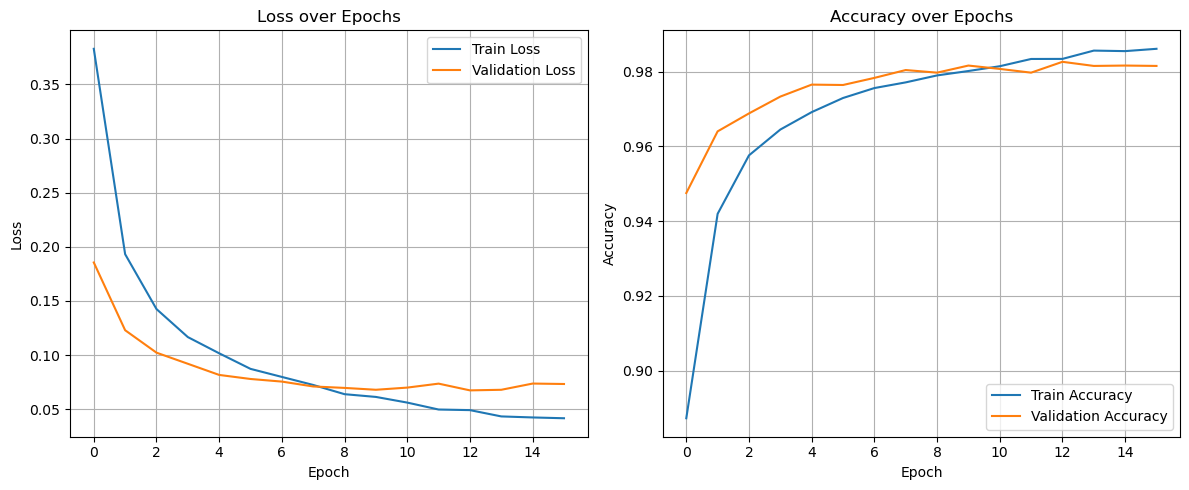

In [183]:
# Build the model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='swish', kernel_regularizer=regularizers.l2(0.0)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_valid, y_valid = x_train[-10000:], y_train[-10000:]
x_train, y_train = x_train[:50000], y_train[:50000]

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    validation_data=(x_valid, y_valid),
    epochs=20,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=0
)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training and validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

